## Implement a pre-trained BERT model for sentiment analysis or text classification on a sample dataset. 

#### Import Libraries

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)

print("Libraries imported successfully!")


d:\Third Year\DL\Assignments\Exp_8\bert_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


#### Check GPU Availability



In [3]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version used by PyTorch:", torch.version.cuda)
else:
    print("GPU not available. Training will use CPU.")


PyTorch version: 2.14.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 2050
CUDA version used by PyTorch: 13.0


#### Set Reproducibility



In [4]:
SEED = 42

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("Random seed set to:", SEED)


Random seed set to: 42


#### Load the Amazon Polarity Dataset

**Amazon Polarity** is a binary sentiment dataset containing Amazon product reviews.

- `0` → Negative
- `1` → Positive

The original dataset is large, so later we will use a manageable subset for practical BERT fine-tuning.

In [5]:
dataset = load_dataset("fancyzhx/amazon_polarity")

print(dataset)


d:\Third Year\DL\Assignments\Exp_8\bert_venv\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Samarth\.cache\huggingface\hub\datasets--fancyzhx--amazon_polarity. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
d:\Third Year\DL\Assignments\Exp_8\bert_venv\lib\site-packages\huggingface_hub\file_download.py

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})


#### Explore the Dataset

In [6]:
print("Training samples:", len(dataset["train"]))
print("Testing samples:", len(dataset["test"]))

print("\nDataset features:")
print(dataset["train"].features)

print("\nFirst training example:")
print(dataset["train"][0])


Training samples: 3600000
Testing samples: 400000

Dataset features:
{'label': ClassLabel(names=['negative', 'positive']), 'title': Value('string'), 'content': Value('string')}

First training example:
{'label': 1, 'title': 'Stuning even for the non-gamer', 'content': 'This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^'}


####  Convert the Dataset to Pandas

Combining the review title and review content gives BERT more textual information for sentiment prediction.

In [7]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

train_df["text"] = (
    train_df["title"].fillna("").astype(str)
    + ". "
    + train_df["content"].fillna("").astype(str)
).str.strip()

test_df["text"] = (
    test_df["title"].fillna("").astype(str)
    + ". "
    + test_df["content"].fillna("").astype(str)
).str.strip()

print(train_df[["text", "label"]].head())


                                                text  label
0  Stuning even for the non-gamer. This sound tra...      1
1  The best soundtrack ever to anything.. I'm rea...      1
2  Amazing!. This soundtrack is my favorite music...      1
3  Excellent Soundtrack. I truly like this soundt...      1
4  Remember, Pull Your Jaw Off The Floor After He...      1


####  Check Class Distribution

A balanced class distribution is useful for binary classification because the model gets a similar number of positive and negative examples.

Training label distribution:
label
0    1800000
1    1800000
Name: count, dtype: int64


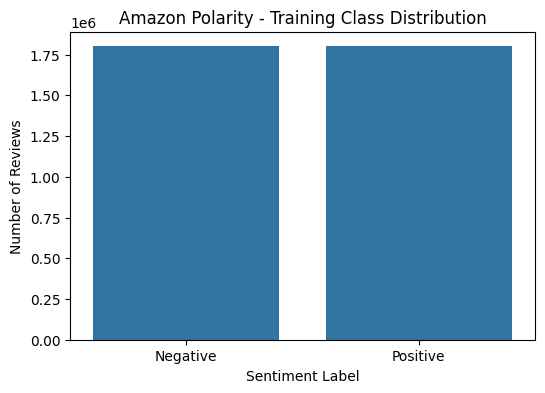

In [8]:
print("Training label distribution:")
print(train_df["label"].value_counts().sort_index())

plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="label")
plt.title("Amazon Polarity - Training Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Reviews")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.show()


#### Create a Manageable Subset

The full Amazon Polarity dataset is large. Fine-tuning BERT on the entire dataset can take a long time and is unnecessary for demonstrating the assignment.

We use **10,000 training reviews** and **2,000 test reviews**. The subset is stratified so both sentiment classes remain represented.

In [9]:
TRAIN_SIZE = 10000
TEST_SIZE = 2000

train_sample, _ = train_test_split(
    train_df,
    train_size=TRAIN_SIZE,
    stratify=train_df["label"],
    random_state=SEED
)

test_sample, _ = train_test_split(
    test_df,
    train_size=TEST_SIZE,
    stratify=test_df["label"],
    random_state=SEED
)

train_sample = train_sample[["text", "label"]].reset_index(drop=True)
test_sample = test_sample[["text", "label"]].reset_index(drop=True)

print("Training subset:", train_sample.shape)
print("Testing subset:", test_sample.shape)
print("\nTraining labels:")
print(train_sample["label"].value_counts().sort_index())


Training subset: (10000, 2)
Testing subset: (2000, 2)

Training labels:
label
0    5000
1    5000
Name: count, dtype: int64


#### Create Training and Validation Sets

We split the 10,000 training reviews into:
- 8,000 training examples
- 2,000 validation examples

The test set remains separate and is used only for final evaluation.

In [10]:
train_data, val_data = train_test_split(
    train_sample,
    test_size=0.20,
    stratify=train_sample["label"],
    random_state=SEED
)

train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(test_sample))


Training samples: 8000
Validation samples: 2000
Test samples: 2000


#### Convert DataFrames to Hugging Face Datasets

In [11]:
train_dataset = Dataset.from_pandas(train_data, preserve_index=False)
val_dataset = Dataset.from_pandas(val_data, preserve_index=False)
test_dataset = Dataset.from_pandas(test_sample, preserve_index=False)

print(train_dataset)
print(val_dataset)
print(test_dataset)


Dataset({
    features: ['text', 'label'],
    num_rows: 8000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})


#### Load the Pretrained BERT Tokenizer

The tokenizer converts normal text into the numerical token representation expected by BERT.

`bert-base-uncased` uses lowercase English text and has been pretrained on large text corpora.

In [12]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)


d:\Third Year\DL\Assignments\Exp_8\bert_venv\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Samarth\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Tokenizer loaded: bert-base-uncased


#### Tokenize the Reviews

BERT accepts a maximum sequence length. We use 256 tokens to keep memory usage and training time manageable.

Long reviews are truncated and shorter reviews are padded dynamically during batching.

In [13]:
MAX_LENGTH = 256

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    desc="Tokenizing training data"
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True,
    desc="Tokenizing validation data"
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True,
    desc="Tokenizing test data"
)

print("Tokenization completed.")


Tokenizing test data: 100%|██████████| 2000/2000 [00:00<00:00, 13136.55 examples/s]

Tokenization completed.


#### Prepare Data Collator

Dynamic padding pads each batch only as much as necessary. This can reduce unnecessary computation compared with padding every review to the same maximum length.

In [15]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Data collator created successfully.")


Data collator created successfully.


#### Load the Pretrained BERT Classification Model

We use BERT with a sequence-classification head containing two output classes:

- Class 0 → Negative
- Class 1 → Positive

The pretrained BERT weights are fine-tuned on Amazon reviews.

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1}
)

print("BERT classification model loaded.")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 283.31it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoin

BERT classification model loaded.


#### Define Evaluation Metrics

During validation, we calculate:
- Accuracy
- Precision
- Recall
- F1-score

F1-score combines precision and recall into a single metric.

In [17]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, zero_division=0)
    recall = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Evaluation function created.")


Evaluation function created.


#### Configure BERT Training

The model is fine-tuned for a small number of epochs. Batch size is kept conservative so the notebook can run on GPUs with limited VRAM.

If your GPU has memory issues, reduce `PER_DEVICE_BATCH_SIZE` to `4`.

In [18]:
PER_DEVICE_BATCH_SIZE = 8
EPOCHS = 2
LEARNING_RATE = 2e-5

training_args = TrainingArguments(
    output_dir="./bert_amazon_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    save_total_limit=1
)

print("Training configuration created.")


Training configuration created.


#### Create the Trainer

The Hugging Face `Trainer` handles batching, optimization, evaluation and checkpointing for the fine-tuning process.

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer created successfully.")


Trainer created successfully.


#### Train / Fine-Tune BERT

This is the main training step. BERT starts with pretrained language knowledge and updates its parameters using the Amazon review sentiment examples.

In [20]:
train_result = trainer.train()

print("\nTraining completed!")
print("Training metrics:")
print(train_result.metrics)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.232080,0.185770,0.938500,0.964021,0.911000,0.936761
2,0.145784,0.217791,0.951000,0.954637,0.947000,0.950803


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.06s/it]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber


Training completed!
Training metrics:
{'train_runtime': 448.4452, 'train_samples_per_second': 35.679, 'train_steps_per_second': 4.46, 'total_flos': 1532309453093760.0, 'train_loss': 0.19289647150039674, 'epoch': 2.0}


#### Evaluate on the Validation Set

In [21]:
validation_results = trainer.evaluate(tokenized_val)

print("Validation Results:")
for key, value in validation_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.145784,0.217791,2,0.951000,0.954637,0.947000,0.950803


Validation Results:
eval_loss: 0.2178
eval_accuracy: 0.9510
eval_precision: 0.9546
eval_recall: 0.9470
eval_f1: 0.9508


#### Evaluate on the Unseen Test Set

The test set was not used for training or validation. This gives a final estimate of how the fine-tuned BERT model performs on unseen reviews.

In [22]:
test_results = trainer.evaluate(tokenized_test)

print("Test Results:")
for key, value in test_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.145784,0.224990,2,0.951500,0.955600,0.947000,0.951281


Test Results:
eval_loss: 0.2250
eval_accuracy: 0.9515
eval_precision: 0.9556
eval_recall: 0.9470
eval_f1: 0.9513


#### Generate Test Predictions

We obtain BERT's predicted sentiment for every review in the test set so that we can create a detailed classification report and confusion matrix.

In [23]:
prediction_output = trainer.predict(tokenized_test)

logits = prediction_output.predictions
y_true = prediction_output.label_ids
y_pred = np.argmax(logits, axis=-1)

print("Predictions generated.")
print("Number of predictions:", len(y_pred))


Predictions generated.
Number of predictions: 2000


#### Classification Report

In [24]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        digits=4,
        zero_division=0
    )
)


              precision    recall  f1-score   support

    Negative     0.9475    0.9560    0.9517      1000
    Positive     0.9556    0.9470    0.9513      1000

    accuracy                         0.9515      2000
   macro avg     0.9515    0.9515    0.9515      2000
weighted avg     0.9515    0.9515    0.9515      2000



#### Calculate Final Evaluation Metrics

In [25]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

results_df


,Metric,Score
0,Accuracy,0.951500
1,Precision,0.955600
2,Recall,0.947000
3,F1-Score,0.951281


#### Plot the Confusion Matrix

The confusion matrix shows:
- True Negative
- False Positive
- False Negative
- True Positive

This helps us understand which sentiment classes the model predicts correctly or incorrectly.

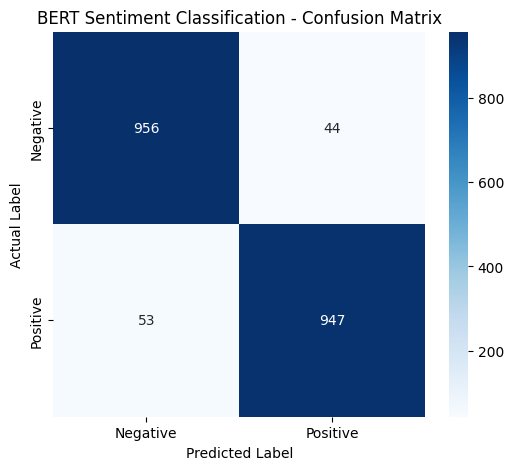

In [26]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("BERT Sentiment Classification - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


#### Plot Training and Validation Loss

The Trainer stores loss values in its training history. The following plot shows how the loss changes during fine-tuning.

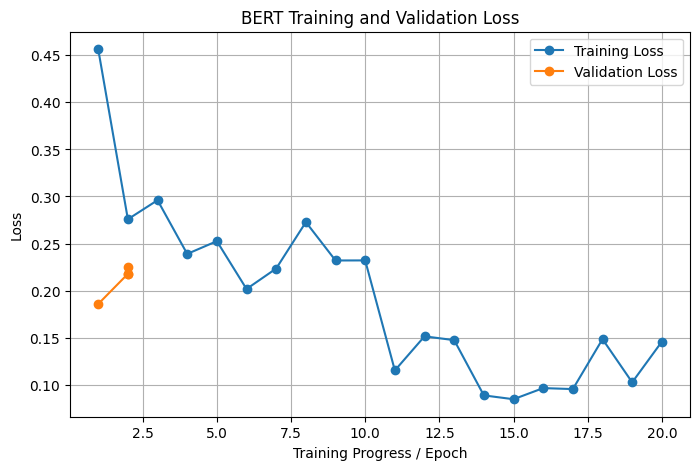

In [27]:
history = trainer.state.log_history

train_loss = [
    entry["loss"]
    for entry in history
    if "loss" in entry and "eval_loss" not in entry
]

eval_loss = [
    entry["eval_loss"]
    for entry in history
    if "eval_loss" in entry
]

eval_epochs = [
    entry["epoch"]
    for entry in history
    if "eval_loss" in entry
]

plt.figure(figsize=(8, 5))

if train_loss:
    plt.plot(
        range(1, len(train_loss) + 1),
        train_loss,
        marker="o",
        label="Training Loss"
    )

if eval_loss:
    plt.plot(
        eval_epochs,
        eval_loss,
        marker="o",
        label="Validation Loss"
    )

plt.title("BERT Training and Validation Loss")
plt.xlabel("Training Progress / Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


#### Plot Evaluation Metrics

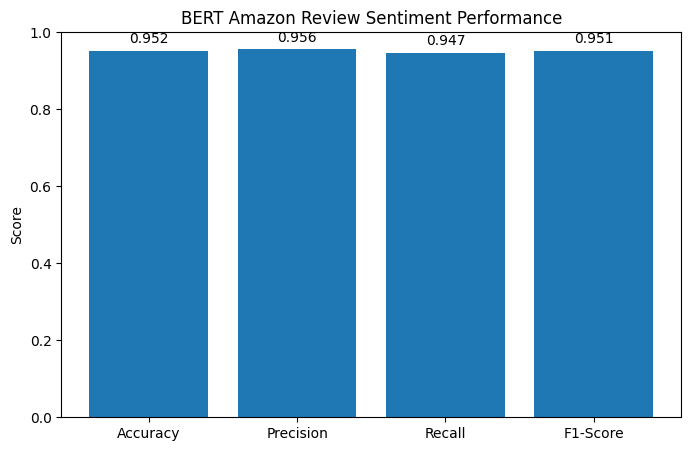

In [28]:
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values)

plt.ylim(0, 1.0)
plt.title("BERT Amazon Review Sentiment Performance")
plt.ylabel("Score")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.show()


#### Test BERT on Custom Reviews

This cell demonstrates how the trained model can classify completely new reviews.

In [29]:
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )

    device = next(model.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)
    prediction = torch.argmax(probabilities, dim=-1).item()
    confidence = probabilities[0][prediction].item()

    label = "Positive" if prediction == 1 else "Negative"

    return label, confidence


custom_reviews = [
    "This product is excellent. I am very happy with the quality.",
    "The product stopped working quickly and I regret buying it.",
    "Amazing quality and fast delivery. I would definitely buy it again.",
    "Very disappointing experience. The product was poorly made."
]

for review in custom_reviews:
    sentiment, confidence = predict_sentiment(review)
    print(f"Review: {review}")
    print(f"Prediction: {sentiment} | Confidence: {confidence:.4f}")
    print("-" * 80)


Review: This product is excellent. I am very happy with the quality.
Prediction: Positive | Confidence: 0.9986
--------------------------------------------------------------------------------
Review: The product stopped working quickly and I regret buying it.
Prediction: Negative | Confidence: 0.9988
--------------------------------------------------------------------------------
Review: Amazing quality and fast delivery. I would definitely buy it again.
Prediction: Positive | Confidence: 0.9988
--------------------------------------------------------------------------------
Review: Very disappointing experience. The product was poorly made.
Prediction: Negative | Confidence: 0.9994
--------------------------------------------------------------------------------


#### Test Your Own Review

Change the text below to any review you want to classify.

In [33]:
my_review = "The product works perfectly and the quality is excellent."

sentiment, confidence = predict_sentiment(my_review)

print("Review:", my_review)
print("Predicted Sentiment:", sentiment)
print("Confidence:", f"{confidence:.4f}")


Review: The product works perfectly and the quality is excellent.
Predicted Sentiment: Positive
Confidence: 0.9986


#### Save the Fine-Tuned Model

Saving the model allows it to be reused later without retraining BERT from the beginning.

In [34]:
SAVE_PATH = "./bert_amazon_sentiment_model"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Model and tokenizer saved to:", SAVE_PATH)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.17s/it]

Model and tokenizer saved to: ./bert_amazon_sentiment_model


#### Final Results

The following cell displays the final test performance in a compact table.

In [32]:
print("===== FINAL TEST RESULTS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")


===== FINAL TEST RESULTS =====
Accuracy : 0.9515
Precision: 0.9556
Recall   : 0.9470
F1-Score : 0.9513


# Conclusion

In this experiment, a pretrained **BERT (`bert-base-uncased`)** model was fine-tuned for binary sentiment classification on the **Amazon Polarity** dataset.

The reviews were tokenized using the BERT tokenizer and the pretrained model was adapted to distinguish between **negative** and **positive** Amazon reviews.

The model was evaluated using **accuracy, precision, recall, F1-score, and a confusion matrix**. Custom review examples were also tested to demonstrate how the fine-tuned BERT model can classify unseen text.

### Key learning outcomes
- Understanding pretrained Transformer models
- Using a BERT tokenizer
- Fine-tuning BERT for text classification
- Using GPU acceleration for deep learning
- Evaluating NLP classification models
- Performing sentiment prediction on new text

